# Assignment Lab 3.2: Unsupervised Learning for Fraud and Anomaly Detection

**Course 02: Introduction to Machine Learning for Cybersecurity**  
**Module 03: Unsupervised Learning**

## Lab Goal
In this assignment, you will apply unsupervised learning techniques to analyze transaction data and identify possible anomalies.

You will use:

- K-Means clustering
- DBSCAN anomaly detection
- PCA for visualization
- Interpretation of clusters and detected anomalies

## Dataset
Use the provided dataset:

`creditcard.csv`

## Important Note
The dataset includes a `Class` column:

- `Class = 0` means normal transaction
- `Class = 1` means fraudulent transaction

For unsupervised learning, do **not** use the `Class` column when training clustering models.  
You may use it later only for comparison and interpretation.


## Step 1: Import Libraries

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

## Step 2: Load the Dataset

Update the file path if your dataset is saved in a different location.


In [2]:
# Load dataset
# Large datasets live in the gitignored /datasets/ folder at the repo root.
# See datasets/README.md for download links.

df = pd.read_csv("../../../datasets/creditcard.csv")

# Display first 5 rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Step 3: Explore the Dataset

In [3]:
# Display dataset shape
print("Dataset shape:", df.shape)

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

# Display dataset information
print("\nDataset information:")
print(df.info())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Display summary statistics
df.describe()

Dataset shape: (284807, 31)

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14    

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## Step 4: Check Class Distribution

Although we will not use `Class` for clustering, we can review it to understand the dataset.


In [4]:
# Check distribution of normal and fraudulent transactions

print(df["Class"].value_counts())

print("\nClass distribution percentage:")
print(df["Class"].value_counts(normalize=True) * 100)

Class
0    284315
1       492
Name: count, dtype: int64

Class distribution percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


## Step 5: Prepare Features for Unsupervised Learning

Two things happen here:

1. **Stratified sampling.** The full dataset has **284,807 rows**. DBSCAN scales
   roughly as O(n²) in time and memory, so running it on the full data is
   impractical. We build a working sample that keeps **every fraud case** plus a
   random subset of **30,000 normal** transactions. This preserves the rare
   fraud signal while keeping clustering and the PCA scatter plots fast and
   readable. (The earlier exploration steps still reflect the full dataset.)

2. **Remove the `Class` column.** Unsupervised models must not see the labels
   during training. We keep `Class` aside for interpretation only.


In [5]:
# Build a stratified working sample: keep ALL frauds + 30,000 random normals
fraud = df[df["Class"] == 1]
normal = df[df["Class"] == 0].sample(n=30000, random_state=42)

df = (
    pd.concat([fraud, normal])
    .sample(frac=1, random_state=42)   # shuffle the rows
    .reset_index(drop=True)
)

print("Working sample shape:", df.shape)
print("\nClass counts in sample:")
print(df["Class"].value_counts())

# Define feature set for unsupervised learning (drop the label)
X = df.drop("Class", axis=1)

print("\nFeatures used for clustering:")
print(X.columns.tolist())

X.head()

Working sample shape: (30492, 31)

Class counts in sample:
Class
0    30000
1      492
Name: count, dtype: int64

Features used for clustering:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,17498.0,1.023025,-0.529432,1.204141,0.269713,-0.772797,0.926465,-0.999453,0.421935,2.301091,...,-0.144557,-0.263774,-0.315828,0.118917,-0.274339,-0.094294,0.943855,-0.040584,-0.004644,40.00
1,62489.0,-1.473491,1.730232,0.981071,3.051009,-0.458966,-0.196955,-0.224677,0.779964,-1.470187,...,0.063403,-0.029205,-0.223131,-0.055006,0.398979,-0.399086,0.016638,-0.072750,0.018165,6.03
2,51795.0,-2.920348,-4.653283,0.369288,0.398617,-3.537493,2.322691,2.927559,0.125220,-1.179214,...,3.215822,0.999373,0.541940,3.065074,-0.423816,0.010252,-0.188201,-0.257743,0.251188,1273.62
3,66619.0,1.423297,-0.984194,-0.231188,-1.440438,-0.861621,-0.613934,-0.476196,-0.243391,-2.195930,...,-0.239191,-0.467059,-1.084730,0.088305,-0.327706,0.301015,-0.404227,0.009874,0.018420,68.73
4,122426.0,2.316909,-0.648789,-1.888607,-1.020784,0.055131,-0.777972,-0.193716,-0.445132,-0.501420,...,0.031543,0.494110,1.640250,-0.302618,-0.872633,0.663631,0.350676,-0.037440,-0.084257,7.00


## Step 6: Scale the Data

Clustering algorithms are sensitive to feature scale, so we standardize the data.


In [6]:
# Scale the dataset

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (30492, 30)


## Step 7: Apply K-Means Clustering

K-Means groups transactions into clusters based on similarity.


In [7]:
# Create and train a K-Means model.
# We use 2 clusters as a starting point: the bulk of "typical" behavior vs.
# a second group that may capture more unusual transactions.
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

# Display cluster counts
print("K-Means cluster sizes:")
print(df["kmeans_cluster"].value_counts().sort_index())

K-Means cluster sizes:
kmeans_cluster
0      213
1    30279
Name: count, dtype: int64


## Step 8: Compare K-Means Clusters with Fraud Labels

Use the `Class` column only for interpretation after clustering.


In [8]:
# Compare K-Means clusters with the Class labels (interpretation only)
ct = pd.crosstab(
    df["kmeans_cluster"],
    df["Class"],
    rownames=["K-Means cluster"],
    colnames=["Class (0=normal, 1=fraud)"],
)
print(ct)

# Fraud rate within each cluster
print("\nFraud rate within each cluster:")
print((ct[1] / ct.sum(axis=1) * 100).round(2).astype(str) + " %")

Class (0=normal, 1=fraud)      0    1
K-Means cluster                      
0                              3  210
1                          29997  282

Fraud rate within each cluster:
K-Means cluster
0    98.59 %
1     0.93 %
dtype: str


## Step 9: Apply PCA for Visualization

PCA reduces the dataset to two components so we can visualize clusters.


In [9]:
# Apply PCA to reduce the scaled data to 2 components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_.round(4))
print("Total variance explained by 2 components:",
      round(pca.explained_variance_ratio_.sum() * 100, 2), "%")

df[["PCA1", "PCA2"]].head()

Explained variance ratio: [0.1536 0.0564]
Total variance explained by 2 components: 21.0 %


,PCA1,PCA2
0,-0.147410,0.226061
1,-0.322348,-0.268899
2,-0.348005,6.720800
3,0.003880,0.051140
4,0.308893,-0.612828


## Step 10: Visualize K-Means Clusters

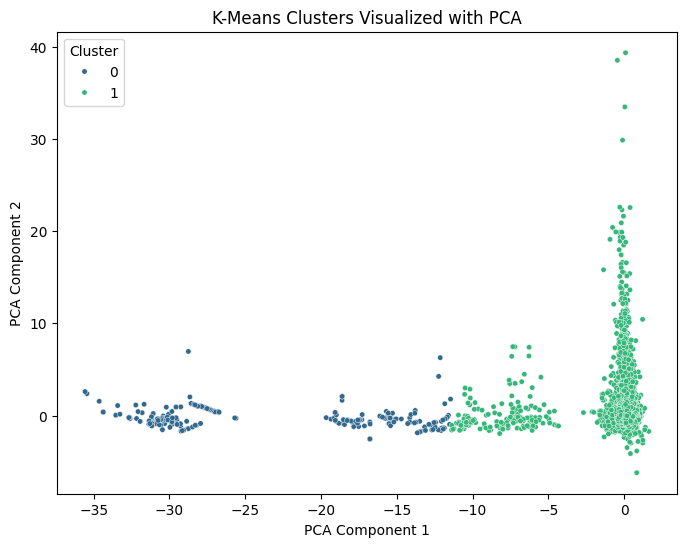

In [10]:
# PCA scatter plot colored by K-Means cluster
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="kmeans_cluster",
    palette="viridis",
    s=15,
)
plt.title("K-Means Clusters Visualized with PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.show()

## Step 11: Apply DBSCAN for Anomaly Detection

DBSCAN identifies dense groups and labels outliers as `-1`.

A label of `-1` may represent possible anomalies.


In [11]:
# Create and train a DBSCAN model with the recommended parameters.
# DBSCAN groups dense regions into clusters and labels low-density points
# as -1 (treated here as possible anomalies).
dbscan = DBSCAN(eps=2.5, min_samples=5)
df["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

print("DBSCAN cluster sizes (-1 = anomaly / noise):")
print(df["dbscan_cluster"].value_counts().sort_index())

n_clusters = df.loc[df["dbscan_cluster"] != -1, "dbscan_cluster"].nunique()
print("\nNumber of dense clusters found (excluding noise):", n_clusters)

DBSCAN cluster sizes (-1 = anomaly / noise):
dbscan_cluster
-1      6123
 0      1147
 1     16700
 2      1399
 3      1980
 4      1295
 5       989
 6        62
 7       122
 8        16
 9        20
 10       95
 11       19
 12       19
 13       25
 14       70
 15        7
 16       36
 17        7
 18       15
 19       15
 20       19
 21       33
 22       35
 23       11
 24        8
 25        9
 26        6
 27        4
 28        6
 29        7
 30        9
 31        6
 32        7
 33       19
 34        9
 35       10
 36        4
 37        6
 38       20
 39       10
 40        4
 41        8
 42        4
 43        6
 44        5
 45        5
 46        6
 47        6
 48        6
 49        5
 50        5
 51        4
 52        5
 53        9
 54        4
 55        6
 56        5
Name: count, dtype: int64

Number of dense clusters found (excluding noise): 57


## Step 12: Identify Possible Anomalies

In [12]:
# Identify records DBSCAN labeled as -1 (possible anomalies)
anomalies = df[df["dbscan_cluster"] == -1]

print("Number of possible anomalies detected:", len(anomalies))
print("Share of sample flagged as anomalous:",
      round(len(anomalies) / len(df) * 100, 2), "%")

anomalies.head()

Number of possible anomalies detected: 6123
Share of sample flagged as anomalous: 20.08 %


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V25,V26,V27,V28,Amount,Class,kmeans_cluster,PCA1,PCA2,dbscan_cluster
2,51795.0,-2.920348,-4.653283,0.369288,0.398617,-3.537493,2.322691,2.927559,0.125220,-1.179214,...,0.010252,-0.188201,-0.257743,0.251188,1273.62,0,1,-0.348005,6.720800,-1
8,64912.0,0.052549,0.201622,1.501389,-0.259521,-0.093897,0.203864,0.304192,-0.287449,-1.048045,...,-0.408716,0.419127,0.020252,-0.064130,11.50,0,1,0.279124,-0.246944,-1
13,150697.0,-1.519626,-0.121069,0.948818,-0.698381,1.628145,0.087435,0.684751,-0.276646,-1.204256,...,0.817169,-0.714973,-0.506212,-0.181163,29.00,0,1,0.550730,-0.613271,-1
17,168444.0,-1.179105,0.804517,0.041392,-1.108087,1.868526,0.885777,1.365781,-0.459974,1.096053,...,-1.075117,0.055204,-0.642458,-0.802373,10.50,0,1,0.278624,-0.504937,-1
19,114599.0,-0.518071,1.601932,0.257580,4.117159,1.566230,2.825158,-0.175925,-1.366302,-1.398103,...,-1.479545,0.393363,-0.090163,0.043643,7.57,0,1,-0.288843,-0.575441,-1


## Step 13: Compare DBSCAN Anomalies with Fraud Labels

Use the `Class` column only after DBSCAN has identified possible anomalies.


In [13]:
# Compare detected anomalies with the Class labels (interpretation only)
if len(anomalies) > 0:
    print("Class distribution among detected anomalies:")
    print(anomalies["Class"].value_counts())

    n_fraud_total = int((df["Class"] == 1).sum())
    n_fraud_flagged = int((anomalies["Class"] == 1).sum())

    recall = n_fraud_flagged / n_fraud_total * 100
    precision = n_fraud_flagged / len(anomalies) * 100

    print(f"\nFrauds flagged as anomalies: {n_fraud_flagged} of {n_fraud_total} "
          f"({recall:.1f}% of all frauds caught)")
    print(f"Precision (frauds among flagged anomalies): {precision:.2f}%")
else:
    print("No anomalies detected. Try adjusting DBSCAN parameters.")

Class distribution among detected anomalies:
Class
0    5715
1     408
Name: count, dtype: int64

Frauds flagged as anomalies: 408 of 492 (82.9% of all frauds caught)
Precision (frauds among flagged anomalies): 6.66%


## Step 14: Visualize DBSCAN Results

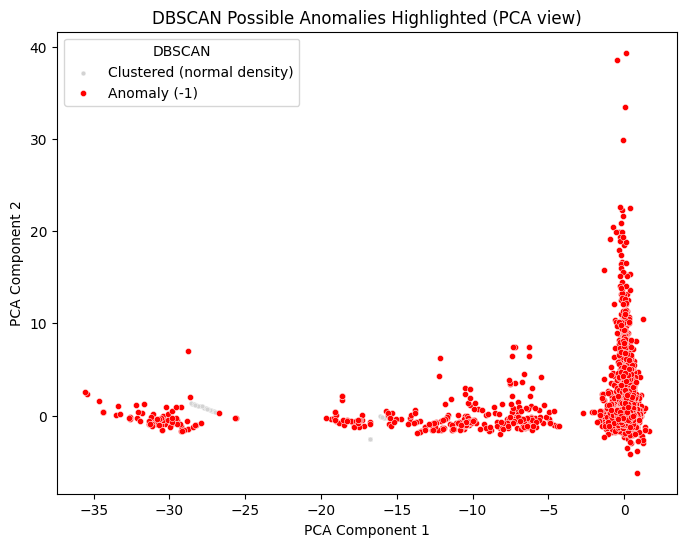

In [14]:
# PCA scatter plot highlighting DBSCAN anomalies vs. clustered points
df["is_anomaly"] = df["dbscan_cluster"] == -1

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df[~df["is_anomaly"]],
    x="PCA1", y="PCA2",
    color="lightgray", s=12, label="Clustered (normal density)",
)
sns.scatterplot(
    data=df[df["is_anomaly"]],
    x="PCA1", y="PCA2",
    color="red", s=20, label="Anomaly (-1)",
)
plt.title("DBSCAN Possible Anomalies Highlighted (PCA view)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="DBSCAN")
plt.show()

## Step 15: Interpretation Questions

### 1. What patterns did you observe in the K-Means clusters?

K-Means split the sample very unevenly. One cluster held the vast majority of
transactions (about 30,279 records) while the other was tiny (about 213
records). The small cluster captured the unusual transactions: it contained
points that sit far from the dense center of the data. This matches the idea
that most transactions behave similarly, and only a small minority look
different.

### 2. Did any cluster appear more associated with fraud than others?

Yes, strongly. Although the model never saw the labels, the small cluster was
about **98.6% fraud** (210 of its 213 records), while the large cluster was only
about **0.9% fraud**. In other words, K-Means concentrated roughly **43% of all
frauds (210 of 492)** into a cluster that makes up well under 1% of the data.
The frauds it isolated are very "pure," but it misses the remaining frauds that
look more like normal transactions.

### 3. How many possible anomalies did DBSCAN identify?

DBSCAN with `eps=2.5, min_samples=5` labeled **6,123 records as `-1`**, about
**20% of the sample**. It also formed 57 small dense clusters. Because the
recommended `eps` is fairly tight for 30-dimensional standardized data, DBSCAN
is aggressive and flags many points as low-density "anomalies."

### 4. Were any DBSCAN anomalies associated with fraudulent transactions?

Yes. Of the 6,123 flagged anomalies, **408 were actual frauds** — meaning DBSCAN
caught **82.9% of all 492 frauds (recall)**. However, only **6.66% of the flagged
records were truly fraudulent (precision)**, since most of the 6,123 anomalies
were unusual-but-legitimate transactions. This is the classic anomaly-detection
trade-off: DBSCAN reaches high recall by casting a wide net, at the cost of many
false positives.

### 5. How did PCA help visualize the dataset?

PCA compressed 30 features into 2 components so the data could be drawn on a 2-D
scatter plot. Even though those two components explain only about **21% of the
total variance**, they were enough to reveal structure: the bulk of normal
transactions form a dense central cloud, while the K-Means outlier cluster and
the DBSCAN `-1` points spread out toward the edges. Without PCA we could not
visually inspect a 30-dimensional space.

### 6. How can unsupervised learning support fraud detection and cybersecurity monitoring?

Unsupervised learning finds unusual behavior **without needing labeled fraud
examples**, which is valuable because real fraud and attacks are rare and often
unlabeled when they first appear. Clustering and anomaly detection can surface
transactions that deviate from normal patterns — unusual amounts, timing, or
feature combinations — and route them to analysts for review. This makes it
useful for catching new ("zero-day") fraud patterns, intrusion attempts, or
account-takeover behavior that a supervised model trained only on known fraud
might miss.

### 7. What are some limitations of unsupervised learning for anomaly detection?

- **Low precision / many false positives.** DBSCAN flagged 20% of the data; only
  ~7% of those were real fraud, so analysts would chase many false alarms.
- **Sensitivity to parameters and scaling.** Results change a lot with `eps`,
  `min_samples`, the number of K-Means clusters, and how features are scaled.
- **No notion of "fraud."** The models only find *statistical* outliers; an
  anomaly is not necessarily malicious, and some fraud looks perfectly normal
  (here, ~57% of frauds were *not* isolated by K-Means).
- **Scalability.** DBSCAN is expensive on large data, which is why we sampled
  rather than running it on all 284,807 rows.
- **Hard to evaluate without labels.** In a true unsupervised setting we would
  not have the `Class` column to confirm whether the anomalies are meaningful.


## Submission Checklist

Before submitting, make sure:

- All code cells run without errors
- Your dataset path is correct
- K-Means clustering is completed
- DBSCAN anomaly detection is completed
- PCA visualizations are included
- Interpretation questions are answered
- Your completed `.ipynb` file is downloaded and submitted in Canvas
